In [2]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from pydantic import BaseModel, Field

In [3]:
load_dotenv()

True

In [4]:
model = init_chat_model("google_genai:gemini-3.7-flash")

In [5]:
class SentimentSchema(BaseModel):
    sentiment: Literal['positive','negative'] = Field(description='Sentiment of the review')

In [6]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [7]:

structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [8]:
class ReviewState(TypedDict):
    review : str
    sentiment: Literal["positive","negative"]
    diagnosis: dict
    response : str

In [ ]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review , find the sentiment \n {state["review"]} '
    sentiment_given = structured_model.invoke(prompt).sentiment
    return {'sentiment':sentiment_given}
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:

    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'

def positive_response(state: ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""

    response = model.invoke(prompt).content

    return {'response': response}

def run_diagnosis(state: ReviewState):

    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)

    return {'diagnosis': response.model_dump()}

def negative_response(state: ReviewState):

    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content

    return {'response': response}

In [11]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)
graph.add_node('positive_response',positive_response)

graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('positive_response',END)
graph.add_edge('negative_response',END)

workflow = graph.compile()

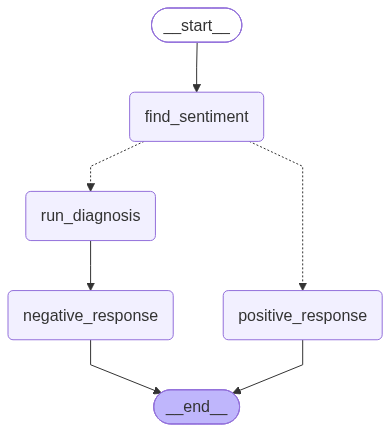

In [12]:
workflow

In [13]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
workflow.invoke(intial_state)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'response': [{'type': 'text',
   'text': '**Subject:** Resolved: [Issue/Ticket Name]\n\nHi [User Name],\n\nI want to start by sincerely apologizing for the frustration and disruption this issue caused you. I know how critical this was and how stressful it is when a bug gets in the way of urgent work.\n\nI’m glad to let you know that our engineering team has deployed a fix, and the issue is now fully resolved. \n\nTo ensure the update takes effect on your end, please:\n1. **Log out and log back in** (or perform a hard refresh in your browser: `Ctrl + F5` on Windows or `Cmd + Shift + R` on Mac).\n2. Try [mention specific action, e.g., submittin